# Baseline 2: EfficientNet-B3

This notebook contains the code for training the **EfficientNet-B3** model on our preprocessed face crops. EfficientNet is a modern CNN family, much newer than Xception, so this gives us a stronger frame-level CNN baseline to compare against.

Same setup as Xception: frame-level CNN, run on each of the 24 frames, average the per-frame logits to get a clip-level prediction. The only thing that changes is the backbone.

**Approach:** Frame-level CNN. Run EfficientNet-B3 on each of the 24 frames, average the per-frame logits.

**Reference:** Tan & Le, *"EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks"*, ICML 2019.

### To view TensorBoard
In PowerShell, use the following command:
```powershell
tensorboard --logdir ./results
```
Open http://localhost:6006 in your browser.

## 1. Setup

In [1]:
# Keep track of time
import time

start_time = time.perf_counter()

In [2]:
# Import nercessary libraries and the shared utilities
import json
from pathlib import Path
import random

import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import timm

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    make_balanced_sampler,
    run_training,
    evaluate,
    load_checkpoint,
    plot_training_curves,
)

In [3]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True

In [4]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"

GPU Name is:NVIDIA GeForce RTX 5080


In [5]:
# Set the hyper-parameter
model_name = "efficientnet_b3_baseline"
# number_of_epochs = 2 # For dry-run
number_of_epochs = 25
batch_size = 8 # 8 clips × 24 frames = 192 frames per batch. EfficientNet-B3 is a bit heavier than Xception per frame but still fits in 16GB VRAM.
learning_rate = 1e-4
weight_decay = 1e-4
early_stopping_patience = 5

## 2. Build datasets and dataloaders

We use the balanced sampler on the train split to oversample reals (since fakes outnumber them 4:1).

In [6]:
# Build the dataset
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

train_dataset = DeepfakeClipDataset(splits_json_path, "train", PREPROCESSED_TENSORS_DIR_PATH, training_augment=True)
validation_dataset = DeepfakeClipDataset(splits_json_path, "validation", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)
test_dataset = DeepfakeClipDataset(splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)

print(f"Train: {len(train_dataset)} clips")
print(f"validation: {len(validation_dataset)} clips")
print(f"Test: {len(test_dataset)} clips")

Train: 2799 clips
validation: 349 clips
Test: 351 clips


In [7]:
# Make the training dataset balanced
train_sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

## 3. Define the model

We use the EfficientNet-B3 backbone from `timm` (pretrained on ImageNet), then replace its classifier with a single-output head, then wrap it so it accepts clip tensors of shape `[B, T, 3, H, W]` and averages over the time dimension.

Note: EfficientNet-B3 was originally trained at 300×300, but we feed 224×224 here to match the other baselines. timm handles the resolution mismatch fine since the network is fully convolutional before the global pool.

In [8]:
class EfficientNetFrameAverager(nn.Module):
    """Run EfficientNet-B3 on each frame independently, average the logits to get a clip score."""
    
    def __init__(self, pretrained=True):
        super().__init__()
        # timm's 'tf_efficientnet_b3' is the ImageNet-pretrained EfficientNet-B3.
        self.backbone = timm.create_model("tf_efficientnet_b3", pretrained=pretrained, num_classes=1)
    
    def forward(self, clip):
        # clip: [B, T, 3, H, W]
        batch_size, number_of_frames, channels, height, width = clip.shape
        
        # Flatten time into batch: [B*T, 3, H, W]
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        
        # Run EfficientNet on every frame: Output: [B*T, 1]
        per_frame_logits = self.backbone(flat_frames)
        
        # Reshape back: [B, T, 1] and average over time
        per_frame_logits = per_frame_logits.view(batch_size, number_of_frames, -1)
        clip_logits = per_frame_logits.mean(dim=1)  # [B, 1]
        return clip_logits


model = EfficientNetFrameAverager(pretrained=True).to(DEVICE)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_parameters:,}  ({num_parameters/1e6:.1f}M)")

Trainable parameters: 10,697,769  (10.7M)


## 4. Optimizer, scheduler, loss

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# We use Cosine annealing as it gradually decays the LR over the training run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs)

loss_function = nn.BCEWithLogitsLoss()

print(f"Optimizer: AdamW, lr={learning_rate}, weight_decay={weight_decay}")
print(f"Scheduler: CosineAnnealingLR over {number_of_epochs} epochs")
print(f"Loss: BCEWithLogitsLoss")

Optimizer: AdamW, lr=0.0001, weight_decay=0.0001
Scheduler: CosineAnnealingLR over 25 epochs
Loss: BCEWithLogitsLoss


## 5. Train

The `run_training` helper from `utils.py` handles the full loop. That is, training epochs, validation, TensorBoard logging, early stopping, and saving the best checkpoint.


In [10]:
best_checkpoint_path = run_training(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function,
    device=DEVICE,
    model_name=model_name,
    number_of_epochs=number_of_epochs,
    early_stopping_patience=early_stopping_patience,
    use_mixed_precision=True,
)


Training: efficientnet_b3_baseline
TensorBoard logs: results\efficientnet_b3_baseline\tensorboard
  Run `tensorboard --logdir C:\x-ion\TEST\results` to view live curves.



Epoch  1/25  train_loss=0.7442  validation_loss=0.6025  validation_auc=0.8889  validation_acc=0.8023  (2404.5s)


Epoch  2/25  train_loss=0.3428  validation_loss=0.3352  validation_auc=0.9534  validation_acc=0.8911  (443.7s) *


Epoch  3/25  train_loss=0.2122  validation_loss=0.1930  validation_auc=0.9744  validation_acc=0.9284  (438.0s) *


Epoch  4/25  train_loss=0.1794  validation_loss=0.1965  validation_auc=0.9842  validation_acc=0.9484  (438.5s) *


...

Epoch 17/25  train_loss=0.0205  validation_loss=0.1139  validation_auc=0.9942  validation_acc=0.9656  (452.9s)


Epoch 18/25  train_loss=0.0209  validation_loss=0.1293  validation_auc=0.9936  validation_acc=0.9685  (452.8s)


Epoch 19/25  train_loss=0.0107  validation_loss=0.1505  validation_auc=0.9918  validation_acc=0.9570  (453.0s)


Epoch 20/25  train_loss=0.0053  validation_loss=0.1050  validation_auc=0.9937  validation_acc=0.9742  (453.2s)


Epoch 21/25  train_loss=0.0083  validation_loss=0.1348  validation_auc=0.9933  validation_acc=0.9628  (452.7s)

Early stopping at epoch 21 (no improvement for 5 epochs).

Training done. Best vvalidation AUC: 0.9944
Best checkpoint: results\efficientnet_b3_baseline\best_model.pt


## 6. Plot training curves

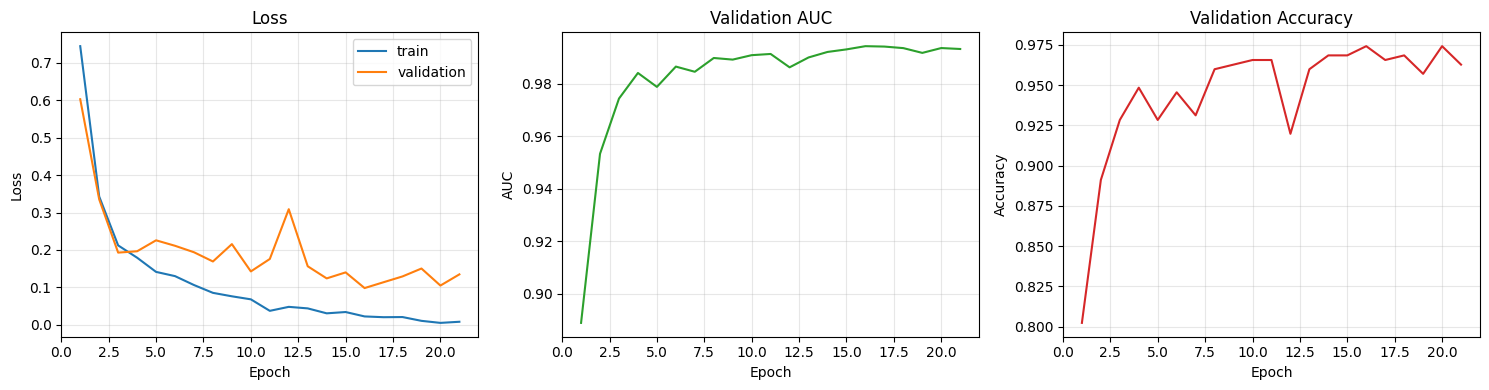

In [11]:
history_path = RESULTS_DIR_PATH / model_name / "training_history.json"
curves_save_path = RESULTS_DIR_PATH / model_name / "training_curves.png"
plot_training_curves(history_path, save_path=curves_save_path)

## 7. Test-set evaluation

Load the best checkpoint and evaluate on the held-out test split. This is the number we'll report in the report.

In [12]:
load_checkpoint(model, best_checkpoint_path, DEVICE)
test_loss, test_metrics, test_predictions = evaluate(model, test_loader, loss_function, DEVICE)

print("\n=== Test set results ===")
print(f"Loss:      {test_loss:.4f}")
print(f"AUC:       {test_metrics['auc']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"Confusion matrix [[TN, FP], [FN, TP]]: {test_metrics['confusion_matrix']}")

# Save for later aggregation across all models
test_metrics_save_path = RESULTS_DIR_PATH / model_name / "final_test_metrics.json"
with open(test_metrics_save_path, "w") as f:
    json.dump({"test_loss": test_loss, "test_metrics": test_metrics}, f, indent=2)

# Also save per-sample predictions for the per-class breakdown later
predictions_save_path = RESULTS_DIR_PATH / model_name / "test_predictions.json"
with open(predictions_save_path, "w") as f:
    json.dump(test_predictions, f, indent=2)

print(f"\nSaved test metrics to {test_metrics_save_path}")


=== Test set results ===
Loss:      0.0638
AUC:       0.9976
Accuracy:  0.9829
Precision: 0.9825
Recall:    0.9964
F1:        0.9894
Confusion matrix [[TN, FP], [FN, TP]]: [[65, 5], [1, 280]]

Saved test metrics to results\efficientnet_b3_baseline\final_test_metrics.json


## 8. Per-manipulation breakdown

Split test-set predictions by manipulation method. This will tells us which fake types EfficientNet handles best.

In [13]:
# Group predictions by class name
predictions_by_class = defaultdict(list)
labels_by_class = defaultdict(list)
for probability, true_label, class_name in zip(
    test_predictions["predicted_probs"],
    test_predictions["true_labels"],
    test_predictions["class_names"],
):
    predictions_by_class[class_name].append(probability)
    labels_by_class[class_name].append(true_label)

print("\n=== Per-class accuracy on test set (threshold = 0.5) ===")
print(f"{'Class':<20} {'N':>4}  {'Accuracy':>10}  {'Mean prob':>10}")
print("-" * 50)
for cls_name in sorted(predictions_by_class.keys()):
    probs = np.array(predictions_by_class[cls_name])
    true_labels = np.array(labels_by_class[cls_name])
    predicted = (probs >= 0.5).astype(int)
    accuracy = (predicted == true_labels).mean()
    print(f"{cls_name:<20} {len(probs):>4}  {accuracy:>10.4f}  {probs.mean():>10.4f}")


=== Per-class accuracy on test set (threshold = 0.5) ===
Class                   N    Accuracy   Mean prob
--------------------------------------------------
Deepfakes              71      1.0000      0.9941
Face2Face              70      1.0000      0.9996
FaceSwap               70      1.0000      0.9999
NeuralTextures         70      0.9857      0.9807
original               70      0.9286      0.0875


In [14]:
end_time = time.perf_counter()
time_elapsed = end_time - start_time
hours_elapsed = int(time_elapsed // 3600)
minutes_elapsed = int((time_elapsed % 3600) // 60)

print(f"Total execution time for {model_name}: {hours_elapsed:,}h {minutes_elapsed}m")

Total execution time for efficientnet_b3_baseline: 3h 9m
